# 12 — Claim Frequency Final Evaluation

## Objectif

Cette étape réalise l'évaluation finale du modèle de fréquence
de sinistre sur le holdout réservé à cette tâche.

La configuration du modèle a été verrouillée avant l'ouverture
de ce holdout.

Modèle retenu :

XGBoost Poisson

Hyperparamètres :

- n_estimators = 500
- learning_rate = 0.08
- max_depth = 6
- min_child_weight = 10
- subsample = 0.7
- colsample_bytree = 0.9
- reg_alpha = 0.01
- reg_lambda = 10

La cible utilisée lors de l'apprentissage correspond à :

ClaimNb / Exposure

avec :

sample_weight = Exposure

Le modèle prédit donc une fréquence attendue.

Le nombre attendu de sinistres est ensuite calculé par :

Expected Claims = Predicted Frequency × Exposure

Aucun changement de modèle ne sera effectué après observation
des résultats du holdout.

In [1]:
import pandas as pd
import numpy as np

import json
import time
import joblib

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer
from sklearn.linear_model import PoissonRegressor

from sklearn.metrics import (
    mean_poisson_deviance,
    mean_absolute_error
)

from xgboost import XGBRegressor


RANDOM_STATE = 42

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    200
)

In [2]:
cwd = Path.cwd()

possible_processed_paths = [
    cwd / "data" / "processed",
    cwd / "data-science" / "data" / "processed",
    cwd.parent / "data" / "processed"
]

PROCESSED_DIR = None

for path in possible_processed_paths:

    if path.exists():

        PROCESSED_DIR = path
        break


if PROCESSED_DIR is None:

    raise FileNotFoundError(
        "Impossible de localiser data/processed"
    )


DATA_DIR = (
    PROCESSED_DIR.parent
)

METADATA_DIR = (
    DATA_DIR
    / "metadata"
)

ARTIFACTS_DIR = (
    DATA_DIR.parent
    / "artifacts"
)

ARTIFACTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_DIR = (
    DATA_DIR.parent
    / "reports"
    / "models"
    / "claim_frequency"
    / "final"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


frequency = pd.read_csv(
    PROCESSED_DIR
    / "claim_frequency_modeling_base.csv"
)

split_df = pd.read_csv(
    METADATA_DIR
    / "freMTPL2_split.csv"
)

In [3]:
with open(
    METADATA_DIR
    / "claim_frequency_candidate.json",
    "r",
    encoding="utf-8"
) as f:

    candidate_config = json.load(f)


print(
    json.dumps(
        candidate_config,
        indent=4
    )
)

{
    "task": "claim_frequency",
    "model": "xgboost_poisson",
    "best_parameters": {
        "n_estimators": 500,
        "learning_rate": 0.08,
        "max_depth": 6,
        "min_child_weight": 10.0,
        "subsample": 0.7,
        "colsample_bytree": 0.9,
        "reg_alpha": 0.01,
        "reg_lambda": 10.0
    },
    "best_cv_poisson_deviance": 0.3028578547775393,
    "best_cv_poisson_deviance_std": 0.001447858816514848,
    "predicted_frequency_mean": 0.10095271249770155,
    "exposure_strategy": "target_rate_with_exposure_sample_weight",
    "test_used": false
}


In [4]:
assert (
    candidate_config[
        "test_used"
    ]
    is False
), (
    "Le holdout Frequency est déjà marqué comme utilisé."
)

print(
    "Configuration candidate chargée : OK"
)

Configuration candidate chargée : OK


In [5]:
with open(
    METADATA_DIR
    / "feature_manifest.json",
    "r",
    encoding="utf-8"
) as f:

    feature_manifest = json.load(f)


config = (
    feature_manifest[
        "claim_frequency"
    ]
)


numeric_features = (
    config[
        "numeric_features"
    ]
)

categorical_features = (
    config[
        "categorical_features"
    ]
)

features = (
    numeric_features
    +
    categorical_features
)

In [6]:
frequency = frequency.merge(
    split_df,
    on="IDpol",
    how="left",
    validate="one_to_one"
)


development = (
    frequency[
        frequency["split"]
        == "development"
    ]
    .copy()
)


test = (
    frequency[
        frequency["split"]
        == "test"
    ]
    .copy()
)


print(
    "Development :",
    development.shape
)

print(
    "Test :",
    test.shape
)

Development : (541431, 13)
Test : (135358, 13)


In [7]:
assert set(
    development["IDpol"]
).isdisjoint(
    set(
        test["IDpol"]
    )
)

print(
    "Holdout integrity : OK"
)

Holdout integrity : OK


In [8]:
X_dev = (
    development[
        features
    ]
    .copy()
)

X_test = (
    test[
        features
    ]
    .copy()
)


y_count_dev = (
    development[
        "ClaimNb"
    ]
    .copy()
)

y_count_test = (
    test[
        "ClaimNb"
    ]
    .copy()
)


exposure_dev = (
    development[
        "Exposure"
    ]
    .copy()
)

exposure_test = (
    test[
        "Exposure"
    ]
    .copy()
)


y_rate_dev = (
    y_count_dev
    /
    exposure_dev
)

In [9]:
assert "ClaimNb" not in X_dev.columns
assert "ClaimNb" not in X_test.columns

assert "Exposure" not in X_dev.columns
assert "Exposure" not in X_test.columns

assert "IDpol" not in X_dev.columns
assert "IDpol" not in X_test.columns

print(
    "Leakage checks : OK"
)

Leakage checks : OK


In [10]:
dev_frequency = (
    y_count_dev.sum()
    /
    exposure_dev.sum()
)

test_frequency = (
    y_count_test.sum()
    /
    exposure_test.sum()
)


print(
    "Development policies :",
    len(development)
)

print(
    "Test policies :",
    len(test)
)

print(
    "DEV frequency :",
    dev_frequency
)

print(
    "TEST frequency :",
    test_frequency
)

Development policies : 541431
Test policies : 135358
DEV frequency : 0.10092303350726638
TEST frequency : 0.10098924510272797


In [11]:
linear_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            linear_numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [12]:
tree_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            tree_numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [13]:
constant_rate = (
    y_count_dev.sum()
    /
    exposure_dev.sum()
)


constant_test_rate = np.full(
    len(test),
    constant_rate,
    dtype=float
)


constant_test_count = (
    constant_test_rate
    *
    exposure_test.to_numpy()
)

In [14]:
BEST_POISSON_ALPHA = 0.001

In [15]:
final_poisson = Pipeline(
    steps=[
        (
            "preprocessor",
            linear_preprocessor
        ),
        (
            "model",
            PoissonRegressor(
                alpha=BEST_POISSON_ALPHA,
                max_iter=1000
            )
        )
    ]
)

In [16]:
start = time.perf_counter()

final_poisson.fit(
    X_dev,
    y_rate_dev,
    model__sample_weight=(
        exposure_dev
    )
)

poisson_training_time = (
    time.perf_counter()
    -
    start
)

In [17]:
poisson_test_rate = (
    final_poisson
    .predict(
        X_test
    )
)


poisson_test_rate = np.clip(
    poisson_test_rate,
    1e-9,
    None
)


poisson_test_count = (
    poisson_test_rate
    *
    exposure_test.to_numpy()
)

In [18]:
BEST_XGB_PARAMS = (
    candidate_config[
        "best_parameters"
    ]
)

BEST_XGB_PARAMS

{'n_estimators': 500,
 'learning_rate': 0.08,
 'max_depth': 6,
 'min_child_weight': 10.0,
 'subsample': 0.7,
 'colsample_bytree': 0.9,
 'reg_alpha': 0.01,
 'reg_lambda': 10.0}

In [19]:
final_xgb = XGBRegressor(
    objective="count:poisson",
    eval_metric="poisson-nloglik",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **BEST_XGB_PARAMS
)

In [20]:
final_xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "model",
            final_xgb
        )
    ]
)

In [21]:
start = time.perf_counter()

final_xgb_pipeline.fit(
    X_dev,
    y_rate_dev,
    model__sample_weight=(
        exposure_dev
    )
)

xgb_training_time = (
    time.perf_counter()
    -
    start
)


print(
    f"Training time : "
    f"{xgb_training_time:.2f} sec"
)

Training time : 33.06 sec


# Ouverture du holdout Claim Frequency

À partir de cette étape, les performances du modèle sont mesurées
sur le holdout réservé à Claim Frequency.

Les hyperparamètres et la stratégie de modélisation ont déjà été
verrouillés.

Les résultats qui suivent ne seront pas utilisés pour effectuer
un nouveau tuning.

In [22]:
xgb_test_rate = (
    final_xgb_pipeline
    .predict(
        X_test
    )
)

xgb_test_rate = np.clip(
    xgb_test_rate,
    1e-9,
    None
)

xgb_test_count = (
    xgb_test_rate
    *
    exposure_test.to_numpy()
)

In [23]:
def evaluate_frequency_predictions(
    model_name,
    y_count,
    exposure,
    predicted_rate,
    predicted_count
):

    observed_frequency = (
        y_count.sum()
        /
        exposure.sum()
    )

    predicted_frequency = (
        predicted_count.sum()
        /
        exposure.sum()
    )

    frequency_bias = (
        predicted_frequency
        -
        observed_frequency
    )

    frequency_bias_pct = (
        frequency_bias
        /
        observed_frequency
        *
        100
    )


    return {
        "model":
            model_name,

        "poisson_deviance":
            mean_poisson_deviance(
                y_count,
                predicted_count
            ),

        "count_mae":
            mean_absolute_error(
                y_count,
                predicted_count
            ),

        "observed_frequency":
            observed_frequency,

        "predicted_frequency":
            predicted_frequency,

        "frequency_bias":
            frequency_bias,

        "frequency_bias_pct":
            frequency_bias_pct,

        "min_predicted_rate":
            predicted_rate.min(),

        "max_predicted_rate":
            predicted_rate.max()
    }

In [24]:
constant_metrics = (
    evaluate_frequency_predictions(
        model_name="constant_frequency",
        y_count=y_count_test,
        exposure=exposure_test,
        predicted_rate=constant_test_rate,
        predicted_count=constant_test_count
    )
)


poisson_metrics = (
    evaluate_frequency_predictions(
        model_name="poisson_regressor",
        y_count=y_count_test,
        exposure=exposure_test,
        predicted_rate=poisson_test_rate,
        predicted_count=poisson_test_count
    )
)


xgb_metrics = (
    evaluate_frequency_predictions(
        model_name="xgboost_poisson",
        y_count=y_count_test,
        exposure=exposure_test,
        predicted_rate=xgb_test_rate,
        predicted_count=xgb_test_count
    )
)

In [25]:
final_comparison = pd.DataFrame([
    constant_metrics,
    poisson_metrics,
    xgb_metrics
]).sort_values(
    "poisson_deviance"
)

final_comparison.round(6)

,model,poisson_deviance,count_mae,observed_frequency,predicted_frequency,frequency_bias,frequency_bias_pct,min_predicted_rate,max_predicted_rate
2,xgboost_poisson,0.301493,0.096294,0.100989,0.100685,-0.000304,-0.301358,0.009201,3.074085
1,poisson_regressor,0.320733,0.099175,0.100989,0.100941,-0.000048,-0.047689,0.001825,3.891890
0,constant_frequency,0.331620,0.100271,0.100989,0.100923,-0.000066,-0.065563,0.100923,0.100923


In [26]:
constant_test_deviance = (
    constant_metrics[
        "poisson_deviance"
    ]
)

poisson_test_deviance = (
    poisson_metrics[
        "poisson_deviance"
    ]
)

xgb_test_deviance = (
    xgb_metrics[
        "poisson_deviance"
    ]
)


xgb_improvement_vs_constant = (
    (
        constant_test_deviance
        -
        xgb_test_deviance
    )
    /
    constant_test_deviance
    *
    100
)


xgb_improvement_vs_poisson = (
    (
        poisson_test_deviance
        -
        xgb_test_deviance
    )
    /
    poisson_test_deviance
    *
    100
)


print(
    f"XGB improvement vs constant : "
    f"{xgb_improvement_vs_constant:.4f}%"
)

print(
    f"XGB improvement vs Poisson : "
    f"{xgb_improvement_vs_poisson:.4f}%"
)

XGB improvement vs constant : 9.0850%
XGB improvement vs Poisson : 5.9988%


In [27]:
test_predictions = pd.DataFrame({
    "IDpol":
        test["IDpol"].values,

    "ClaimNb":
        y_count_test.values,

    "Exposure":
        exposure_test.values,

    "predicted_frequency":
        xgb_test_rate,

    "predicted_claim_count":
        xgb_test_count
})

In [28]:
test_predictions[
    "risk_decile"
] = pd.qcut(
    test_predictions[
        "predicted_frequency"
    ],
    q=10,
    labels=False,
    duplicates="drop"
)

In [29]:
decile_analysis = (
    test_predictions
    .groupby(
        "risk_decile"
    )
    .agg(
        policies=(
            "IDpol",
            "size"
        ),

        exposure=(
            "Exposure",
            "sum"
        ),

        observed_claims=(
            "ClaimNb",
            "sum"
        ),

        predicted_claims=(
            "predicted_claim_count",
            "sum"
        )
    )
)

In [30]:
decile_analysis[
    "observed_frequency"
] = (
    decile_analysis[
        "observed_claims"
    ]
    /
    decile_analysis[
        "exposure"
    ]
)


decile_analysis[
    "predicted_frequency"
] = (
    decile_analysis[
        "predicted_claims"
    ]
    /
    decile_analysis[
        "exposure"
    ]
)


decile_analysis[
    "prediction_ratio"
] = (
    decile_analysis[
        "predicted_frequency"
    ]
    /
    decile_analysis[
        "observed_frequency"
    ]
)


decile_analysis

,policies,exposure,observed_claims,predicted_claims,observed_frequency,predicted_frequency,prediction_ratio
risk_decile,,,,,,,
0,13536,8298.277421,283,319.591908,0.034103,0.038513,1.129300
1,13536,7704.438144,354,408.549237,0.045948,0.053028,1.154094
2,13536,7496.393135,478,464.701785,0.063764,0.061990,0.972179
3,13535,7653.238069,543,533.672147,0.070950,0.069732,0.982822
4,13536,7745.203422,630,596.770697,0.081341,0.077050,0.947255
5,13536,7725.316881,658,656.498156,0.085174,0.084980,0.997718
6,13535,7394.364106,698,702.313883,0.094396,0.094980,1.006180
7,13536,6544.760850,793,734.963005,0.121166,0.112298,0.926813
8,13536,6079.662855,958,930.413732,0.157575,0.153037,0.971204


In [31]:
portfolio_frequency = (
    y_count_test.sum()
    /
    exposure_test.sum()
)

highest_decile = (
    decile_analysis
    .iloc[-1]
)

top_decile_frequency = (
    highest_decile[
        "observed_frequency"
    ]
)

top_decile_lift = (
    top_decile_frequency
    /
    portfolio_frequency
)


print(
    "Portfolio frequency :",
    portfolio_frequency
)

print(
    "Top decile observed frequency :",
    top_decile_frequency
)

print(
    "Top decile lift :",
    top_decile_lift
)

Portfolio frequency : 0.10098924510272797
Top decile observed frequency : 0.37015912854971
Top decile lift : 3.6653321665408813


In [32]:
top_decile_claim_share = (
    highest_decile[
        "observed_claims"
    ]
    /
    y_count_test.sum()
)


top_decile_exposure_share = (
    highest_decile[
        "exposure"
    ]
    /
    exposure_test.sum()
)


print(
    "Top decile claim share :",
    top_decile_claim_share
)

print(
    "Top decile exposure share :",
    top_decile_exposure_share
)

Top decile claim share : 0.2539067902088231
Top decile exposure share : 0.06927251847093711


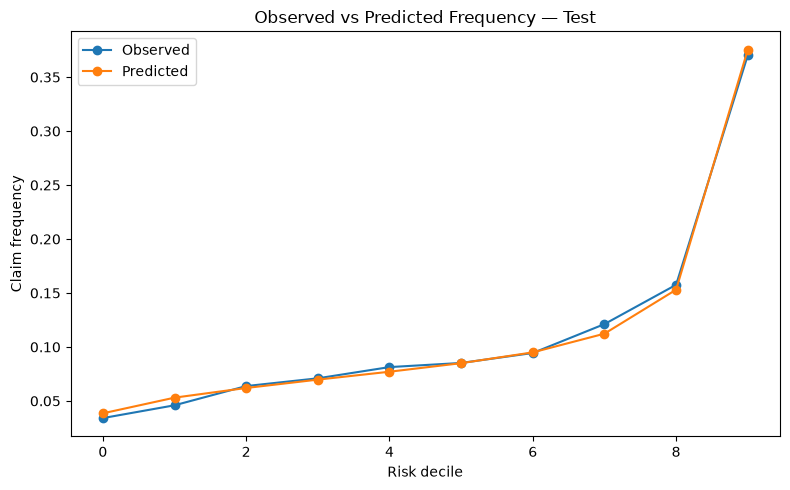

In [33]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    decile_analysis.index,
    decile_analysis[
        "observed_frequency"
    ],
    marker="o",
    label="Observed"
)

plt.plot(
    decile_analysis.index,
    decile_analysis[
        "predicted_frequency"
    ],
    marker="o",
    label="Predicted"
)

plt.xlabel(
    "Risk decile"
)

plt.ylabel(
    "Claim frequency"
)

plt.title(
    "Observed vs Predicted Frequency — Test"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "frequency_observed_vs_predicted_deciles.png",
    dpi=150
)

plt.show()

In [34]:
final_comparison.to_csv(
    REPORT_DIR
    / "frequency_final_model_comparison.csv",
    index=False
)

test_predictions.to_csv(
    REPORT_DIR
    / "frequency_test_predictions.csv",
    index=False
)

decile_analysis.to_csv(
    REPORT_DIR
    / "frequency_decile_analysis.csv"
)

In [35]:
MODEL_PATH = (
    ARTIFACTS_DIR
    / "claim_frequency_xgboost_poisson.joblib"
)

joblib.dump(
    final_xgb_pipeline,
    MODEL_PATH
)

print(
    MODEL_PATH
)

c:\Users\user\ai-business-advisor-v2\data-science\artifacts\claim_frequency_xgboost_poisson.joblib


In [36]:
loaded_frequency_model = joblib.load(
    MODEL_PATH
)


sample_X = (
    X_test
    .head(10)
    .copy()
)


original_predictions = (
    final_xgb_pipeline
    .predict(
        sample_X
    )
)


reloaded_predictions = (
    loaded_frequency_model
    .predict(
        sample_X
    )
)


np.testing.assert_allclose(
    original_predictions,
    reloaded_predictions
)


print(
    "Reload test : OK"
)

Reload test : OK


In [37]:
def python_value(value):

    if isinstance(
        value,
        np.generic
    ):

        return value.item()

    return value

In [38]:
final_frequency_metadata = {

    "model_name":
        "claim_frequency_xgboost_poisson",

    "model_version":
        "1.0.0",

    "target_definition":
        "ClaimNb / Exposure",

    "exposure_strategy":
        "Exposure used as sample_weight",

    "output":
        "expected claim frequency per exposure unit",

    "expected_count_formula":
        "predicted_frequency * Exposure",

    "features":
        features,

    "hyperparameters":
        BEST_XGB_PARAMS,

    "holdout_metrics":
        {
            key:
                python_value(value)

            for key, value
            in xgb_metrics.items()
        },

    "top_decile_lift":
        python_value(
            top_decile_lift
        ),

    "artifact":
        MODEL_PATH.name
}

In [39]:
with open(
    METADATA_DIR
    / "claim_frequency_model_v1.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        final_frequency_metadata,
        f,
        indent=4,
        ensure_ascii=False
    )

In [40]:
candidate_config[
    "test_used"
] = True

candidate_config[
    "test_evaluation_completed"
] = True

In [41]:
with open(
    METADATA_DIR
    / "claim_frequency_candidate.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        candidate_config,
        f,
        indent=4,
        ensure_ascii=False
    )

In [42]:
print(
    "=" * 80
)

print(
    "CLAIM FREQUENCY — FINAL HOLDOUT RESULTS"
)

print(
    "=" * 80
)


print(
    "\n=== DATA ==="
)

print(
    "Development policies :",
    len(development)
)

print(
    "Test policies :",
    len(test)
)

print(
    "Development claims :",
    y_count_dev.sum()
)

print(
    "Test claims :",
    y_count_test.sum()
)

print(
    "Development exposure :",
    exposure_dev.sum()
)

print(
    "Test exposure :",
    exposure_test.sum()
)


print(
    "\n=== PORTFOLIO FREQUENCY ==="
)

print(
    "Development frequency :",
    dev_frequency
)

print(
    "Test frequency :",
    test_frequency
)


print(
    "\n=== FINAL MODEL ==="
)

print(
    "Model : XGBoost Poisson"
)

for key, value in (
    BEST_XGB_PARAMS.items()
):

    print(
        key,
        "=",
        value
    )


print(
    "\n=== MODEL COMPARISON ON HOLDOUT ==="
)

print(
    final_comparison
    .round(6)
    .to_string(
        index=False
    )
)


print(
    "\n=== XGBOOST PERFORMANCE ==="
)

print(
    "Poisson Deviance :",
    xgb_metrics[
        "poisson_deviance"
    ]
)

print(
    "Count MAE :",
    xgb_metrics[
        "count_mae"
    ]
)

print(
    "Observed frequency :",
    xgb_metrics[
        "observed_frequency"
    ]
)

print(
    "Predicted frequency :",
    xgb_metrics[
        "predicted_frequency"
    ]
)

print(
    "Frequency bias (%) :",
    xgb_metrics[
        "frequency_bias_pct"
    ]
)


print(
    "\n=== IMPROVEMENT ==="
)

print(
    "vs Constant :",
    f"{xgb_improvement_vs_constant:.4f}%"
)

print(
    "vs PoissonRegressor :",
    f"{xgb_improvement_vs_poisson:.4f}%"
)


print(
    "\n=== RISK SEGMENTATION ==="
)

print(
    "Portfolio frequency :",
    portfolio_frequency
)

print(
    "Top decile observed frequency :",
    top_decile_frequency
)

print(
    "Top decile lift :",
    top_decile_lift
)

print(
    "Top decile claim share :",
    top_decile_claim_share
)

print(
    "Top decile exposure share :",
    top_decile_exposure_share
)


print(
    "\n=== DECILE CALIBRATION ==="
)

print(
    decile_analysis
    .round(6)
    .to_string()
)


print(
    "\n=== ARTIFACT ==="
)

print(
    MODEL_PATH
)

print(
    "Reload test : OK"
)


print(
    "\nFREQUENCY HOLDOUT UTILISÉ : OUI"
)

print(
    "RETUNING APRÈS HOLDOUT : NON"
)


print(
    "=" * 80
)

CLAIM FREQUENCY — FINAL HOLDOUT RESULTS

=== DATA ===
Development policies : 541431
Test policies : 135358
Development claims : 28817
Test claims : 7231
Development exposure : 285534.42161372607
Test exposure : 71601.68384905248

=== PORTFOLIO FREQUENCY ===
Development frequency : 0.10092303350726638
Test frequency : 0.10098924510272797

=== FINAL MODEL ===
Model : XGBoost Poisson
n_estimators = 500
learning_rate = 0.08
max_depth = 6
min_child_weight = 10.0
subsample = 0.7
colsample_bytree = 0.9
reg_alpha = 0.01
reg_lambda = 10.0

=== MODEL COMPARISON ON HOLDOUT ===
             model  poisson_deviance  count_mae  observed_frequency  predicted_frequency  frequency_bias  frequency_bias_pct  min_predicted_rate  max_predicted_rate
   xgboost_poisson          0.301493   0.096294            0.100989             0.100685       -0.000304           -0.301358            0.009201            3.074085
 poisson_regressor          0.320733   0.099175            0.100989             0.100941       -0

## Évaluation finale du modèle de fréquence de sinistre

Le modèle retenu pour l'estimation de la fréquence de sinistre
est un XGBoost utilisant un objectif Poisson.

La modélisation est effectuée sur le taux :

ClaimNb / Exposure

et l'exposition est utilisée comme poids d'apprentissage.

Le nombre attendu de sinistres est ensuite obtenu par :

Expected Claims = Predicted Frequency × Exposure

### Données du holdout

Le holdout contient :

- 135 358 polices ;
- 7 231 sinistres ;
- 71 601.68 unités d'exposition.

La fréquence observée est :

**0.100989 sinistre par unité d'exposition.**

### Performances

Les résultats obtenus sont :

| Modèle | Poisson Deviance | Count MAE |
|---|---:|---:|
| Constant Frequency | 0.331620 | 0.100271 |
| PoissonRegressor | 0.320733 | 0.099175 |
| XGBoost Poisson | **0.301493** | **0.096294** |

XGBoost réduit la Poisson deviance de :

- **9.09 %** par rapport à la baseline constante ;
- **6.00 %** par rapport à PoissonRegressor.

Le modèle XGBoost offre donc la meilleure capacité à représenter
l'hétérogénéité de fréquence entre les contrats.

### Calibration globale

La fréquence observée sur le holdout est :

**0.100989**

La fréquence moyenne prédite est :

**0.100685**

Le biais relatif est donc d'environ :

**-0.30 %**

Le modèle présente ainsi une très bonne calibration au niveau global
du portefeuille.

### Analyse par déciles de risque

Les contrats ont été répartis en dix groupes selon leur fréquence prédite.

La fréquence observée augmente nettement entre les groupes à faible
risque et les groupes à risque élevé.

Le décile présentant les scores les plus élevés atteint une fréquence
observée de :

**0.3702**

contre :

**0.1010**

pour l'ensemble du portefeuille.

Le lift du décile supérieur est ainsi :

**3.665**

Le groupe de risque le plus élevé représente environ :

**6.93 % de l'exposition totale**

tout en concentrant :

**25.39 % des sinistres observés.**

Cette analyse montre que le modèle est capable de segmenter efficacement
le portefeuille selon la fréquence de sinistre attendue.

### Calibration locale

Les fréquences prédites sont généralement proches des fréquences
réellement observées dans les différents déciles.

Certains écarts subsistent néanmoins dans les groupes présentant
les fréquences les plus faibles, où le modèle tend légèrement
à surestimer le risque.

Cette observation souligne l'importance d'analyser non seulement
la calibration globale du portefeuille mais également la calibration
par segment.

### Généralisation

La Poisson deviance obtenue pendant le tuning était d'environ :

**0.3029**

et celle observée sur le holdout est :

**0.3015**

Les performances du modèle restent donc cohérentes entre les phases
de validation et d'évaluation finale.

Cette stabilité constitue un indicateur favorable de généralisation.

### Interprétation de la sortie

La sortie du modèle représente une fréquence attendue et non
une probabilité.

Une valeur supérieure à 1 est donc mathématiquement possible.

Pour obtenir le nombre attendu de sinistres pour une police,
la fréquence prédite est multipliée par son exposition.